In [ ]:
print("Hello")

Hello


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

#DGEX Transcriptomics Project

In [ ]:
import pandas as pd
# Loading the Expression Matrix from TCGA, downloaded from UCSC Xena
# The data is log2 normalised
data = pd.read_csv("/TCGA_BRCA_STAR_Counts_Expression.tsv", sep="\t")
data.head()

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
0,ENSG00000000003.15,11.737670,9.781360,13.122504,11.016808,11.000000,9.614710,11.092096,12.103616,12.417325,...,10.747354,10.360847,10.675957,11.337064,11.697836,12.339850,12.131857,8.974415,13.326289,9.710806
1,ENSG00000000005.6,7.721099,3.321928,0.000000,6.686501,3.807355,4.087463,5.392317,3.000000,3.321928,...,1.584963,2.000000,1.000000,8.164907,0.000000,2.807355,3.906891,3.700440,3.807355,1.000000
2,ENSG00000000419.13,11.042343,11.357552,11.506308,10.801708,11.074141,11.107217,10.318543,11.160502,11.072803,...,10.429407,10.811375,10.835261,10.693487,11.922213,11.221587,10.913637,11.659550,10.962173,12.416270
3,ENSG00000000457.14,11.036860,10.754888,12.218260,11.190442,10.857981,8.539159,11.527966,10.635718,9.945444,...,10.366322,10.558421,11.262682,10.751544,10.607330,10.163650,10.575539,11.929258,11.403012,10.870365
4,ENSG00000000460.17,9.131857,8.721099,10.973697,10.761551,9.550747,8.550747,9.177420,9.727920,10.504819,...,8.661778,9.000000,9.794416,9.231221,9.782998,9.252665,8.632995,10.562242,10.060696,9.722808


In [ ]:
# Loading the probe ids along with the gene names, downloaded from UCSC Xena
probemap = pd.read_csv(
    "/gencode.v36.annotation.gtf.gene.probemap",
    sep="\t"
)

probemap.head()

,id,gene,chrom,chromStart,chromEnd,strand
0,ENSG00000223972.5,DDX11L1,chr1,11869,14409,+
1,ENSG00000227232.5,WASH7P,chr1,14404,29570,-
2,ENSG00000278267.1,MIR6859-1,chr1,17369,17436,-
3,ENSG00000243485.5,MIR1302-2HG,chr1,29554,31109,+
4,ENSG00000284332.1,MIR1302-2,chr1,30366,30503,+


In [ ]:
# Converting ENSG IDs to Gene Names in Expression Matrix using Probemap document
expr_mapped = data.merge(
    probemap[["id", "gene"]],
    left_on="Ensembl_ID",
    right_on="id",
    how="left"
)
expr_mapped.head()
expr_mapped = expr_mapped.dropna(subset=["gene"]) #Removing unmapped genes
expr_mapped = expr_mapped.drop_duplicates(subset=["gene"]) #Removing duplicates
expr_mapped.set_index("gene", inplace=True) #Setting gene column as Index

expr_mapped = expr_mapped.drop(
    columns=["Ensembl_ID", "id"]
)  #Removing Ensembl ID and id columns
expr_mapped.head()
expr_matrix = expr_mapped.transpose()
expr_matrix.head()

gene,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AL451106.1,AC092910.4,AC073611.1,AC136977.1,AC078856.1,AC008763.4,AL592295.6,AC006486.3,AL391628.1,AP006621.6
TCGA-D8-A146-01A,11.737670,7.721099,11.042343,11.036860,9.131857,9.136991,11.869594,11.004923,11.345405,11.671541,...,0.0,0.0,5.321928,0.0,0.0,0.0,8.184875,0.0,2.807355,4.954196
TCGA-AQ-A0Y5-01A,9.781360,3.321928,11.357552,10.754888,8.721099,7.774787,11.902752,12.030322,11.074141,11.624339,...,0.0,0.0,3.906891,0.0,0.0,0.0,9.584963,0.0,2.807355,5.247928
TCGA-C8-A274-01A,13.122504,0.000000,11.506308,12.218260,10.973697,7.954196,10.239599,11.017504,10.817783,12.313166,...,0.0,0.0,5.392317,0.0,0.0,0.0,9.942515,0.0,3.906891,4.321928
TCGA-BH-A0BD-01A,11.016808,6.686501,10.801708,11.190442,10.761551,8.810572,11.800091,11.179287,10.715104,11.683433,...,0.0,0.0,4.392317,0.0,1.0,0.0,9.590587,0.0,3.000000,3.807355
TCGA-B6-A1KC-01B,11.000000,3.807355,11.074141,10.857981,9.550747,7.294621,11.249113,11.325868,10.832890,12.506803,...,0.0,0.0,5.672425,0.0,0.0,0.0,10.625709,0.0,2.321928,3.807355


In [ ]:
# Loading Landmark Genes (n=987) from L1000 Assay
landmarks = pd.read_csv("/landmark_genes.csv")
landmark_genes = landmarks["gene"].tolist()
landmark_genes

['PSME1',
 'CISD1',
 'SPDEF',
 'ATF1',
 'RHEB',
 'IGF1R',
 'FOXO3',
 'GSTM2',
 'RHOA',
 'IL1B',
 'ASAH1',
 'RALA',
 'ARHGEF12',
 'SOX2',
 'SERPINE1',
 'HLA-DMA',
 'EGF',
 'SPTLC2',
 'APP',
 'TSKU',
 'TMEM2',
 'NOS3',
 'CSNK1A1',
 'NFATC4',
 'TBP',
 'SLC2A6',
 'EZH2',
 'ICAM3',
 'BRCA1',
 'PSMD4',
 'PHKG2',
 'ETV1',
 'KDM5B',
 'COG4',
 'MCM3',
 'TERT',
 'SNX13',
 'PAK4',
 'DPH2',
 'SNX6',
 'EED',
 'WIPF2',
 'NENF',
 'RPN1',
 'C2CD2L',
 'GABPB1',
 'POLR2K',
 'PTK2B',
 'PAF1',
 'POLR1C',
 'RUVBL1',
 'AKT1',
 'SENP6',
 'HSPB1',
 'EBP',
 'CASK',
 'RRP8',
 'PIK3C3',
 'BHLHE40',
 'BDH1',
 'SH3BP5',
 'PPP2R5A',
 'EML3',
 'BIRC5',
 'EPRS',
 'PAX8',
 'CBLB',
 'PDS5A',
 'DFFB',
 'TGFB3',
 'XBP1',
 'NMT1',
 'ARFIP2',
 'STAMBP',
 'PRKX',
 'FAH',
 'PLP2',
 'SOX4',
 'TESK1',
 'HN1L',
 'RRAGA',
 'ELOVL6',
 'ACBD3',
 'PMAIP1',
 'TWF2',
 'HDAC6',
 'CCND1',
 'PXN',
 'PHKB',
 'NFKBIB',
 'CASC3',
 'MLEC',
 'GLI2',
 'USP22',
 'TMED10',
 'CHERP',
 'PIK3CA',
 'TRAPPC6A',
 'ATP2C1',
 'USP14',
 'APPBP2',
 'RPS6

In [ ]:
# Mapping Landmark gene list to Expression Matrix
available_landmarks = [
    gene for gene in landmark_genes
    if gene in expr_matrix.columns
]
X = expr_matrix[available_landmarks]  #Input Matrix
X.head()
# Mapping Target gene list to Expression Matrix
target_genes = [
    gene for gene in expr_matrix.columns
    if gene not in available_landmarks
]
Y = expr_matrix[target_genes]  #Target Genes

In [ ]:
print(X.shape)
print(Y.shape)
# Train - Test Split (80% - Training, 20% - Testing)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras import Input

(1226, 934)
(1226, 58493)


In [ ]:
# Building Neural Network
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    #Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(y_train.shape[1])
])
# Compile Model
model.compile(
    optimizer='adam',
    loss='mse'
)
# Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)
# Make Predictions of Target Gene Expression
predictions = model.predict(X_test)
#Evaluate Performance
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
# Calculate Correlation
import numpy as np
corr = np.corrcoef(
    y_test.values.flatten(),
    predictions.flatten()
)[0,1]
print("Correlation:", corr)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - loss: 7.8351 - val_loss: 1.7323
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 1.7620 - val_loss: 1.2256
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 1.5223 - val_loss: 1.6793
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 1.5065 - val_loss: 1.3365
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - loss: 1.4485 - val_loss: 1.5186
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 1.4104 - val_loss: 1.2472
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 1.4230 - val_loss: 2.2110
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 1.4029 - val_loss: 1.4679
Epoch 9/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 1.4024 - val_loss: 1.4885
Epoch 10/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - loss: 1.4188 - val_loss: 1.4232
Epoch 11/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 1.4170 - val_loss: 1.2789
Epoch 12/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 

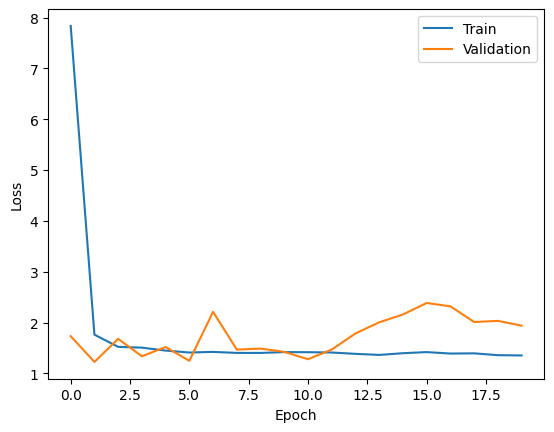

In [ ]:
# Plot Training Loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

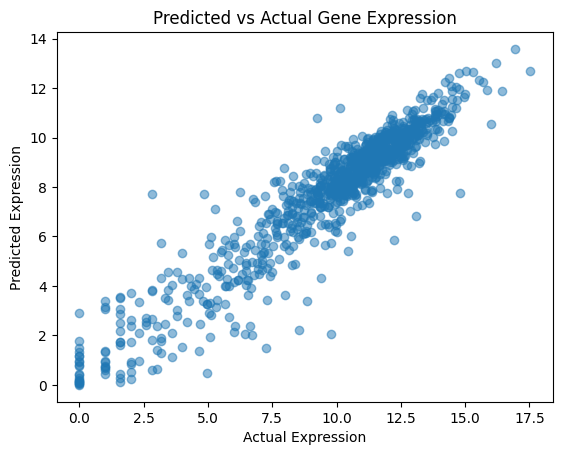

In [ ]:
# Plot Predicted vs Actual Expression
import matplotlib.pyplot as plt

true_vals = y_test.values.flatten()[:1000]
pred_vals = predictions.flatten()[:1000]

plt.scatter(true_vals, pred_vals, alpha=0.5)

plt.xlabel("Actual Expression")
plt.ylabel("Predicted Expression")

plt.title("Predicted vs Actual Gene Expression")

plt.show()

In [ ]:
# Gene-Wise Correlation
gene_correlations = {}

for gene in y_test.columns:
    corr = np.corrcoef(
        y_test[gene],
        predictions[:, y_test.columns.get_loc(gene)]
    )[0,1]

    gene_correlations[gene] = corr
# Comverting to Data Frame
corr_df = pd.DataFrame({
    "Gene": gene_correlations.keys(),
    "Correlation": gene_correlations.values()
})

corr_df.sort_values(
    by="Correlation",
    ascending=False
).head(20)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Gene,Correlation
1463,YTHDC1,0.868201
10797,HNRNPK,0.850352
3037,NRF1,0.848710
4843,SEPTIN7,0.841658
4479,FKBP15,0.834033
657,THRAP3,0.833385
1826,CDC23,0.828336
10144,PPP1R21,0.827624
1888,SH3GLB1,0.826852
9878,MAML1,0.825476


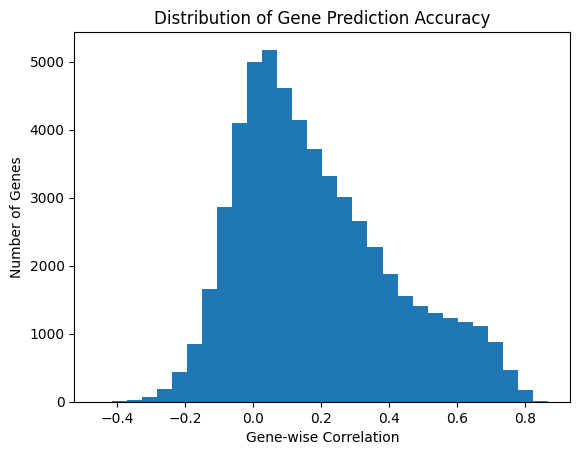

,Gene,Correlation
20358,RNU6-1111P,-0.460088
22637,SNORA36B,-0.431201
36452,EGFLAM-AS3,-0.406048
22757,RNA5SP328,-0.404835
33500,MTND4LP3,-0.402852
46737,MIR4282,-0.399174
38659,RNY4P20,-0.398445
55788,AC005232.1,-0.392804
24271,DNAJC19P4,-0.389935
26010,AC021035.1,-0.389034


In [ ]:
# Distribution of Gene Correlations
plt.hist(corr_df["Correlation"], bins=30)

plt.xlabel("Gene-wise Correlation")
plt.ylabel("Number of Genes")

plt.title("Distribution of Gene Prediction Accuracy")

plt.show()
# Hardest Genes to Predict
corr_df.sort_values(
    by="Correlation"
).head(20)

In [ ]:
model.save("/dgex_model.h5")

In [ ]:
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [ ]:
import os

project_path = "/drive/MyDrive/dgex_project"

os.makedirs(project_path, exist_ok=True)

print("Project folder created!")
data.to_csv(
    f"{project_path}/original_tcga_expression_matrix.csv",
    index=False
)
probemap.to_csv(
    f"{project_path}/probemap.csv",
    index=False
)
expr_mapped.to_csv(
    f"{project_path}/mapped_expression_matrix.csv"
)
expr_matrix.to_csv(
    f"{project_path}/ml_ready_expression_matrix.csv"
)
X.to_csv(
    f"{project_path}/X_landmark_matrix.csv"
)
Y.to_csv(
    f"{project_path}/Y_target_matrix.csv"
)
model.save(
    f"{project_path}/dgex_model.h5"
)
pred_df = pd.DataFrame(
    predictions,
    columns=y_test.columns
)

pred_df.to_csv(
    f"{project_path}/predictions.csv",
    index=False
)
corr_df.to_csv(
    f"{project_path}/gene_correlations.csv",
    index=False
)
plt.savefig(
    f"{project_path}/loss_curve.png"
)


Project folder created!


<Figure size 640x480 with 0 Axes>